<a href="https://colab.research.google.com/github/reinan-silvaa/INTELIGENCIA-ARTIFICIAl/blob/main/DataScience_Ele%C3%A7%C3%B5es_1936.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise da Pesquisa Literary Digest de 1936
Neste notebook iremos realizar a preparação, limpeza e análise exploratória dos dados históricos das eleições de 1932 e da pesquisa da Literary Digest de 1936.

O objetivo é organizar as bases para investigar o erro histórico da pesquisa, que previu a vitória de Landon, mas Roosevelt venceu com folga.

## Preparação e Limpeza dos Dados

Nesta etapa serão importados e organizados os dados das eleições de 1932 e 1936. O processo inclui o carregamento das planilhas, verificação da estrutura dos dados, tratamento de valores ausentes, remoção de colunas vazias e identificação de registros duplicados.

A base de 1936 contém os resultados da pesquisa da Literary Digest, enquanto a de 1932 poderá ser utilizada para comparações históricas. Ao final, os dados estarão limpos e organizados para as próximas análises.

### **1. Importação das bibliotecas**

Serão importadas as bibliotecas necessárias para carregar, organizar, limpar e visualizar os dados.

In [ ]:
# Pandas: leitura, organização e limpeza dos dados
import pandas as pd

# NumPy: suporte para operações numéricas
import numpy as np

# Matplotlib: criação de gráficos
import matplotlib.pyplot as plt

# Seaborn: gráficos estatísticos mais elaborados
import seaborn as sns

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


**Explicação:** O pandas cuida das tabelas, o NumPy das operações numéricas e o matplotlib/seaborn dos gráficos.

### 2. Carregamento do dataset

O arquivo LitDigestFull.xlsx possui diferentes planilhas com dados históricos das eleições. Ele será enviado diretamente pelo Google Colab.

In [ ]:
# Abre a janela de upload do Colab
from google.colab import files
# Faz o upload do arquivo para o ambiente
uploaded = files.upload()

Saving LitDigestFull.xlsx to LitDigestFull (6).xlsx


**Explicação:** O files.upload() abre uma janela para enviar o arquivo .xlsx. Depois do upload, ele fica disponível na pasta de trabalho do Colab.

### 3. Identificação das planilhas disponíveis
Antes de escolher quais bases usar, é preciso ver quais planilhas existem dentro do arquivo Excel.

In [ ]:
# Nome do arquivo enviado
arquivo = "LitDigestFull.xlsx"

# Abre o arquivo Excel sem carregar os dados ainda
excel = pd.ExcelFile(arquivo)

# Cabeçalho do resumo
print("PLANILHAS DISPONÍVEIS")
print("—" * 30)

# Mostra cada planilha encontrada
for planilha in excel.sheet_names:
    print(f"• {planilha}")

PLANILHAS DISPONÍVEIS
——————————————————————————————
• 1924
• 1928
• 1932
• 1936


**Explicação:** O pd.ExcelFile() abre o arquivo sem carregar as planilhas. O sheet_names mostra o nome de cada uma, o que evita carregar bases desnecessárias.

### 4. Seleção das bases
Serão utilizadas as planilhas de 1932 e 1936. A de 1936 tem os dados principais da pesquisa. A de 1932 serve como referência histórica para comparação.

In [ ]:
# Carrega a planilha de 1932 (os nomes reais das colunas estão na linha 1)
df_1932 = pd.read_excel(arquivo, sheet_name="1932", header=1)

# Carrega a planilha de 1936
df_1936 = pd.read_excel(arquivo, sheet_name="1936", header=1)

# Mostra um resumo das dimensões
print("BASES CARREGADAS")
print("—" * 35)
print(f"1932 -> {df_1932.shape[0]} linhas | {df_1932.shape[1]} colunas")
print(f"1936 -> {df_1936.shape[0]} linhas | {df_1936.shape[1]} colunas")

BASES CARREGADAS
———————————————————————————————————
1932 -> 51 linhas | 45 colunas
1936 -> 50 linhas | 56 colunas


**Explicação:** O header=1 indica que a primeira linha da planilha é decorativa e os nomes das colunas estão na segunda linha. O shape mostra quantas linhas e colunas cada base possui.

### 5. Visualização inicial dos dados
Antes de mexer em qualquer coisa, vamos olhar as primeiras linhas para conferir se o carregamento funcionou.

In [ ]:
# Mostra só 5 linhas e 8 colunas de 1932
print("AMOSTRA DA BASE DE 1932")
display(df_1932.iloc[:5, :8])

# Mostra o mesmo resumo para 1936
print("\nAMOSTRA DA BASE DE 1936")
display(df_1936.iloc[:5, :8])

AMOSTRA DA BASE DE 1932


,Unnamed: 0,Electoral Votes,1932 Total Vote,Rep.,Dem.,Other,Did Not Vote,Unnamed: 7
0,ALABAMA,11.0,4272,3150,480,1,641,NaN
1,ARIZONA,3.0,2574,2022,218,1,333,NaN
2,ARKANSAS,9.0,3712,2997,250,1,464,NaN
3,CALIFORNIA,22.0,81834,67017,3847,99,10871,NaN
4,COLORADO,6.0,11950,9870,603,4,1473,NaN



AMOSTRA DA BASE DE 1936


,State,Electoral Vote,Landon,Rep.,Dem.,Soc.,Others,Did Not Vote
0,Alabama,11,3060,1218,1298,3,3,412
1,Arizona,3,2337,1431,647,18,0,129
2,Arkansas,9,2724,1338,953,7,9,274
3,California,22,89516,65360,16200,315,53,3519
4,Colorado,6,15949,11872,2714,131,12,637


**Explicação:** O iloc[:5, :8] mostra apenas as 5 primeiras linhas e 8 primeiras colunas, evitando uma tabela gigante na tela.

###  6. Verificação da estrutura das colunas
Algumas colunas são apenas separadores visuais da planilha e aparecem como Unnamed. Elas precisam ser identificadas antes da limpeza.

In [ ]:
# Conta colunas que o nome começa com "Unnamed" em 1932
unnamed_1932 = [c for c in df_1932.columns if str(c).startswith("Unnamed")]

# Faz o mesmo para 1936
unnamed_1936 = [c for c in df_1936.columns if str(c).startswith("Unnamed")]

# Mostra um resumo da estrutura
print("ESTRUTURA DAS BASES")
print("—" * 35)
print(f"1932 -> {len(df_1932.columns)} colunas | {len(unnamed_1932)} Unnamed")
print(f"1936 -> {len(df_1936.columns)} colunas | {len(unnamed_1936)} Unnamed")

ESTRUTURA DAS BASES
———————————————————————————————————
1932 -> 45 colunas | 8 Unnamed
1936 -> 56 colunas | 4 Unnamed


**Explicação:** Colunas Unnamed geralmente são espaços em branco que sobraram da planilha original. Saber quantas existem ajuda a planejar a limpeza.

### 7. Identificação de valores ausentes
Vamos separar dois casos: colunas totalmente vazias (podem ser removidas) e colunas com ausências pontuais (serão preservadas).

In [ ]:
# Função que resume os valores ausentes de uma base
def resumo_ausentes(df, ano):

    # Conta ausentes por coluna
    ausentes = df.isna().sum()

    # Colunas 100% vazias
    colunas_vazias = ausentes[ausentes == len(df)]

    # Colunas com ausência apenas parcial
    ausencias_parciais = ausentes[(ausentes > 0) & (ausentes < len(df))]

    print(f"VALORES AUSENTES - {ano}")
    print("—" * 35)
    print(f"Colunas totalmente vazias   : {len(colunas_vazias)}")
    print(f"Colunas com ausência parcial: {len(ausencias_parciais)}")
    print(f"Total de valores ausentes   : {int(ausentes.sum())}")

# Executa para cada base
resumo_ausentes(df_1932, 1932)
print()
resumo_ausentes(df_1936, 1936)

VALORES AUSENTES - 1932
———————————————————————————————————
Colunas totalmente vazias   : 8
Colunas com ausência parcial: 18
Total de valores ausentes   : 461

VALORES AUSENTES - 1936
———————————————————————————————————
Colunas totalmente vazias   : 5
Colunas com ausência parcial: 21
Total de valores ausentes   : 292


**Explicação:** A função separa o que é coluna totalmente vazia do que é coluna com ausência parcial. Essa distinção é importante porque nem toda ausência significa que a coluna ou linha não será importante.

### 8. Identificação das colunas completamente vazias
Antes de remover, vamos registrar quais colunas estão totalmente vazias.

In [ ]:
# Seleciona as colunas em que TODAS as linhas são nulas
vazias_1932 = df_1932.columns[df_1932.isna().all()].tolist()
vazias_1936 = df_1936.columns[df_1936.isna().all()].tolist()

print("COLUNAS COMPLETAMENTE VAZIAS")
print("—" * 40)

# Lista as colunas vazias de 1932
print("1932:")
for coluna in vazias_1932:
    print(f"• {coluna}")

# Lista as colunas vazias de 1936
print("\n1936:")
for coluna in vazias_1936:
    print(f"• {coluna}")

COLUNAS COMPLETAMENTE VAZIAS
————————————————————————————————————————
1932:
• Unnamed: 7
• Unnamed: 8
• Unnamed: 14
• Unnamed: 15
• Unnamed: 23
• Unnamed: 25
• Unnamed: 26
• https://en.wikipedia.org/wiki/1932_United_States_presidential_election

1936:
• Unnamed: 9
• Unnamed: 17
• Unnamed: 25
• Unnamed: 33
• https://en.wikipedia.org/wiki/1936_United_States_presidential_election


**Explicação:** O isna().all() retorna True só para colunas em que todas as linhas são nulas.

### 9. Remoção das colunas vazias
Agora removemos apenas as colunas sem nenhuma informação.

In [ ]:
# Guarda a quantidade de colunas antes da limpeza
antes_1932 = df_1932.shape[1]
antes_1936 = df_1936.shape[1]

# Remove colunas totalmente vazias
df_1932 = df_1932.dropna(axis=1, how="all")
df_1936 = df_1936.dropna(axis=1, how="all")

# Calcula quantas foram removidas
removidas_1932 = antes_1932 - df_1932.shape[1]
removidas_1936 = antes_1936 - df_1936.shape[1]

print("LIMPEZA DAS COLUNAS")
print("—" * 35)
print(f"1932 -> {removidas_1932} colunas vazias removidas")
print(f"1936 -> {removidas_1936} colunas vazias removidas")

LIMPEZA DAS COLUNAS
———————————————————————————————————
1932 -> 8 colunas vazias removidas
1936 -> 5 colunas vazias removidas


Explicação: O dropna(axis=1, how="all") remove colunas em que todas as linhas estão vazias. Colunas com informações parciais continuam intactas.

### 10. Padronização dos nomes das colunas
Os nomes das colunas serão padronizados: minúsculos, sem espaços extras e com underline no lugar de espaços.

In [ ]:
# Função que padroniza os nomes das colunas
def padronizar_colunas(df):

    # Cria cópia para não alterar o original
    df = df.copy()

    # Converte os nomes para texto
    df.columns = df.columns.astype(str)

    # Remove espaços no início e no fim
    df.columns = df.columns.str.strip()

    # Deixa tudo minúsculo
    df.columns = df.columns.str.lower()

    # Troca espaços por underline
    df.columns = df.columns.str.replace(" ", "_", regex=False)

    return df

# Aplica a padronização nas duas bases
df_1932 = padronizar_colunas(df_1932)
df_1936 = padronizar_colunas(df_1936)

print("PADRONIZAÇÃO")
print("—" * 35)
print("Colunas de 1932 padronizadas")
print("Colunas de 1936 padronizadas")

PADRONIZAÇÃO
———————————————————————————————————
Colunas de 1932 padronizadas
Colunas de 1936 padronizadas


**Explicação:** A padronização altera só os nomes das colunas, sem tocar nos dados. Depois disso fica mais fácil referenciar qualquer coluna no código.

### 11. Organização da coluna de estados
A primeira coluna de 1932 representa os estados. Vamos renomear para state e remover espaços extras.

In [ ]:
# Pega o nome da primeira coluna de 1932
primeira_coluna_1932 = df_1932.columns[0]

# Renomeia essa coluna para "state"
df_1932 = df_1932.rename(columns={primeira_coluna_1932: "state"})

# Remove espaços extras dos nomes de estado nas duas bases
df_1932["state"] = df_1932["state"].astype(str).str.strip()
df_1936["state"] = df_1936["state"].astype(str).str.strip()

print("ORGANIZAÇÃO DOS ESTADOS")
print("—" * 35)
print("Coluna 'state' organizada em 1932")
print("Coluna 'state' organizada em 1936")

ORGANIZAÇÃO DOS ESTADOS
———————————————————————————————————
Coluna 'state' organizada em 1932
Coluna 'state' organizada em 1936


**Explicação:** O strip() remove espaços no começo e no fim do texto, evitando que "Alabama  " e "Alabama" sejam tratados como diferentes.

### 12. Verificação de registros duplicados
Linhas completamente iguais podem gerar contagens erradas. Vamos verificar e remover.

In [ ]:
# Conta duplicados antes da limpeza
duplicados_1932 = df_1932.duplicated().sum()
duplicados_1936 = df_1936.duplicated().sum()

# Remove linhas duplicadas
df_1932 = df_1932.drop_duplicates()
df_1936 = df_1936.drop_duplicates()

print("REGISTROS DUPLICADOS")
print("—" * 35)
print(f"1932 -> {duplicados_1932} duplicados encontrados")
print(f"1936 -> {duplicados_1936} duplicados encontrados")

REGISTROS DUPLICADOS
———————————————————————————————————
1932 -> 0 duplicados encontrados
1936 -> 0 duplicados encontrados


**Explicação**: O duplicated() marca as linhas repetidas e o drop_duplicates() as remove.

### 13. Organização das principais colunas
Vamos renomear as colunas mais importantes para nomes mais claros, usados nas próximas etapas.

In [ ]:
# Mapeamento de nomes da base de 1932
renomear_1932 = {
    "1932_total_vote": "total_poll_1932",
    "rep.": "previous_rep_1932",
    "dem.": "previous_dem_1932",
    "other": "previous_other_1932",
    "did_not_vote": "previous_no_vote_1932"
}

# Mapeamento de nomes da base de 1936
renomear_1936 = {
    "electoral_vote": "electoral_votes",
    "landon": "landon_poll",
    "roosevelt_(d)": "roosevelt_poll",
    "lemke": "lemke_poll",
    "total": "total_poll_1936"
}

# Aplica só nas colunas que existem de fato
df_1932.rename(
    columns={a: n for a, n in renomear_1932.items() if a in df_1932.columns},
    inplace=True
)

df_1936.rename(
    columns={a: n for a, n in renomear_1936.items() if a in df_1936.columns},
    inplace=True
)

print("ORGANIZAÇÃO DAS COLUNAS")
print("—" * 35)
print("Principais colunas de 1932 organizadas")
print("Principais colunas de 1936 organizadas")

ORGANIZAÇÃO DAS COLUNAS
———————————————————————————————————
Principais colunas de 1932 organizadas
Principais colunas de 1936 organizadas


**Explicação:** O rename() troca nomes antigos por novos. O if in df.columns evita erro caso alguma coluna não exista na planilha.

### 14. Criação das bases para análise
As bases possuem registros que não são estados, como Totals e State unknown. Vamos criar cópias só para a análise e remover esses registros nelas.

In [ ]:
# Cria cópias das bases limpas
dados_1932 = df_1932.copy()
dados_1936 = df_1936.copy()

# Registros que não representam estados
registros_especiais = ["totals", "totals:", "state unknown"]

# Remove esses registros das cópias (o ~ inverte a seleção)
dados_1932 = dados_1932[~dados_1932["state"].str.lower().isin(registros_especiais)].copy()
dados_1936 = dados_1936[~dados_1936["state"].str.lower().isin(registros_especiais)].copy()

# Reinicia a numeração das linhas
dados_1932.reset_index(drop=True, inplace=True)
dados_1936.reset_index(drop=True, inplace=True)

print("BASES PARA ANÁLISE")
print("—" * 35)
print(f"1932 -> {dados_1932.shape[0]} registros")
print(f"1936 -> {dados_1936.shape[0]} registros")

BASES PARA ANÁLISE
———————————————————————————————————
1932 -> 49 registros
1936 -> 48 registros


**Explicação:** O ~ inverte a seleção: mantemos apenas os registros que NÃO estão na lista. O reset_index(drop=True) reinicia a numeração das linhas.

### 15. Verificação dos tipos de dados
Antes de calcular qualquer coisa, é bom saber quantas colunas são numéricas e quantas viraram texto.

In [ ]:
# Função que resume os tipos de dados de uma base
def resumo_tipos(df, ano):

    # Conta colunas numéricas
    numericas = df.select_dtypes(include=np.number).shape[1]

    # O resto é considerado "outras"
    outras = df.shape[1] - numericas

    print(f"TIPOS DE DADOS - {ano}")
    print("—" * 35)
    print(f"Colunas numéricas : {numericas}")
    print(f"Outras colunas    : {outras}")
    print(f"Total de colunas  : {df.shape[1]}")

# Executa nas duas bases
resumo_tipos(dados_1932, 1932)
print()
resumo_tipos(dados_1936, 1936)

TIPOS DE DADOS - 1932
———————————————————————————————————
Colunas numéricas : 29
Outras colunas    : 8
Total de colunas  : 37

TIPOS DE DADOS - 1936
———————————————————————————————————
Colunas numéricas : 37
Outras colunas    : 14
Total de colunas  : 51


**Explicação:** O select_dtypes(include=np.number) filtra só as colunas numéricas. Isso evita descobrir tarde demais que uma coluna de votos foi lida como texto.

### 16. Verificação dos valores ausentes restantes
Mesmo depois da limpeza ainda pode haver ausências. Vamos identificá-las.

In [ ]:
# Função que lista as colunas ainda com ausências
def verificar_ausentes(df, ano):

    # Conta ausentes por coluna
    ausentes = df.isna().sum()

    # Mantém só as colunas com pelo menos 1 ausente
    ausentes = ausentes[ausentes > 0]

    print(f"VALORES AUSENTES RESTANTES - {ano}")
    print("—" * 42)

    # Se não há nenhum, avisa
    if len(ausentes) == 0:
        print("Nenhum valor ausente encontrado.")
    else:
        print(f"Colunas afetadas : {len(ausentes)}")
        print(f"Total de ausentes: {int(ausentes.sum())}")

# Executa nas duas bases
verificar_ausentes(dados_1932, 1932)
print()
verificar_ausentes(dados_1936, 1936)

VALORES AUSENTES RESTANTES - 1932
——————————————————————————————————————————
Colunas afetadas : 17
Total de ausentes: 18

VALORES AUSENTES RESTANTES - 1936
——————————————————————————————————————————
Colunas afetadas : 21
Total de ausentes: 21


**Explicação:** As ausências restantes não serão substituídas por zero, porque isso distorceria os cálculos. Serão tratadas quando necessário em cada análise.

### 17. Verificação de valores inválidos
As principais colunas eleitorais devem ser numéricas. Se houver texto no meio, isso precisa aparecer.

In [ ]:
# Colunas que devem ser numéricas em cada base
colunas_numericas_1932 = [
    "electoral_votes", "total_poll_1932",
    "previous_rep_1932", "previous_dem_1932",
    "previous_other_1932", "previous_no_vote_1932"
]

colunas_numericas_1936 = [
    "electoral_votes", "landon_poll",
    "roosevelt_poll", "lemke_poll", "total_poll_1936"
]

# Mantém só as que existem de fato
colunas_numericas_1932 = [c for c in colunas_numericas_1932 if c in df_1932.columns]
colunas_numericas_1936 = [c for c in colunas_numericas_1936 if c in df_1936.columns]

# Função que conta valores que não podem virar número
def contar_invalidos(df, colunas):

    total_invalidos = 0

    for coluna in colunas:

        # Tenta converter para número (o que não der vira NaN)
        convertido = pd.to_numeric(df[coluna], errors="coerce")

        # Conta valores que existiam mas não viraram número
        invalidos = (convertido.isna() & df[coluna].notna()).sum()

        total_invalidos += invalidos

    return total_invalidos

# Aplica nas duas bases
invalidos_1932 = contar_invalidos(df_1932, colunas_numericas_1932)
invalidos_1936 = contar_invalidos(df_1936, colunas_numericas_1936)

print("VALIDAÇÃO NUMÉRICA")
print("—" * 35)
print(f"1932 -> {invalidos_1932} valores inválidos")
print(f"1936 -> {invalidos_1936} valores inválidos")

VALIDAÇÃO NUMÉRICA
———————————————————————————————————
1932 -> 0 valores inválidos
1936 -> 0 valores inválidos


**Explicação:** A ideia é tentar converter cada valor para número. Se algum valor que existia não puder virar número, ele é contado como inválido.

### 18. Padronização dos dados numéricos
Agora convertemos explicitamente as principais colunas para formato numérico.

In [ ]:
# Converte as variáveis de 1932
for coluna in colunas_numericas_1932:
    df_1932[coluna] = pd.to_numeric(df_1932[coluna], errors="coerce")

# Converte as variáveis de 1936
for coluna in colunas_numericas_1936:
    df_1936[coluna] = pd.to_numeric(df_1936[coluna], errors="coerce")

print("PADRONIZAÇÃO NUMÉRICA")
print("—" * 35)
print("Dados numéricos de 1932 padronizados")
print("Dados numéricos de 1936 padronizados")

PADRONIZAÇÃO NUMÉRICA
———————————————————————————————————
Dados numéricos de 1932 padronizados
Dados numéricos de 1936 padronizados


**Explicação:** O errors="coerce" transforma qualquer valor inválido em NaN. Isso é mais seguro do que deixar um texto se passar por número.

### 19. Verificação dos estados duplicados
Como as análises serão por estado, é importante checar se há repetições.

In [ ]:
# Mantém só registros com estado informado
estados_1932 = df_1932[df_1932["state"].notna()]
estados_1936 = df_1936[df_1936["state"].notna()]

# Conta nomes de estado repetidos
duplicados_estado_1932 = estados_1932["state"].duplicated().sum()
duplicados_estado_1936 = estados_1936["state"].duplicated().sum()

print("VALIDAÇÃO DOS ESTADOS")
print("—" * 35)
print(f"1932 -> {duplicados_estado_1932} estados duplicados")
print(f"1936 -> {duplicados_estado_1936} estados duplicados")

VALIDAÇÃO DOS ESTADOS
———————————————————————————————————
1932 -> 0 estados duplicados
1936 -> 0 estados duplicados


**Explicação:** Um estado aparecendo duas vezes causaria somas erradas. Por isso a checagem vem antes de qualquer análise.

### 20. Conferência final da preparação
Vamos resumir o resultado de toda a limpeza.

In [ ]:
# Função que mostra o resumo final de uma base
def resumo_final(df, ano):

    print(f"BASE {ano}")
    print("—" * 35)
    print(f"Registros          : {df.shape[0]}")
    print(f"Colunas            : {df.shape[1]}")
    print(f"Duplicados         : {df.duplicated().sum()}")
    print(f"Valores ausentes   : {df.isna().sum().sum()}")

print("     RESUMO FINAL DA LIMPEZA")
print()

# Mostra o resumo das duas bases
resumo_final(dados_1932, 1932)
print()
resumo_final(dados_1936, 1936)

     RESUMO FINAL DA LIMPEZA

BASE 1932
———————————————————————————————————
Registros          : 49
Colunas            : 37
Duplicados         : 0
Valores ausentes   : 18

BASE 1936
———————————————————————————————————
Registros          : 48
Colunas            : 51
Duplicados         : 0
Valores ausentes   : 21


**Explicação:** Esse é o boletim da limpeza. Depois dele, as bases estão prontas para a análise exploratória.

### 21. Exportação dos dados preparados
As bases finais serão exportadas em CSV para serem reutilizadas sem refazer toda a limpeza.

In [ ]:
# Salva a base de 1932 em CSV
dados_1932.to_csv("LitDigest_1932_limpo.csv", index=False)

# Salva a base de 1936 em CSV
dados_1936.to_csv("LitDigest_1936_limpo.csv", index=False)

print("EXPORTAÇÃO CONCLUÍDA")
print("—" * 35)
print("LitDigest_1932_limpo.csv")
print("LitDigest_1936_limpo.csv")

EXPORTAÇÃO CONCLUÍDA
———————————————————————————————————
LitDigest_1932_limpo.csv
LitDigest_1936_limpo.csv


**Explicação**: O index=False evita criar uma coluna extra com o índice das linhas no CSV.

## Conclusão da preparação
Nesta etapa, as bases históricas de 1932 e 1936 foram carregadas, inspecionadas e limpas. Foram removidas colunas totalmente vazias, padronizados os nomes das colunas, tratados os nomes de estados e convertidas as variáveis numéricas.

Um cuidado importante foi não substituir valores ausentes por zero, pois cada ausência precisa ser interpretada no contexto da variável.

## Análise Exploratória dos Dados (EDA)
Vamos investigar como os votos estavam distribuídos, quais estados participaram mais e como 1932 se compara a 1936.

### 22. Estatísticas descritivas
Primeiro, um panorama geral das variáveis da pesquisa de 1936.

In [ ]:
# Variáveis que serão analisadas
variaveis_1936 = ["landon_poll", "roosevelt_poll", "lemke_poll", "total_poll_1936"]

# Mantém só as que existem
variaveis_1936 = [c for c in variaveis_1936 if c in dados_1936.columns]

# Mostra estatísticas básicas (média, desvio, quartis, etc.)
display(dados_1936[variaveis_1936].describe().round(2))

,landon_poll,roosevelt_poll,lemke_poll,total_poll_1936
count,48.00,48.00,48.00,48.00
mean,26802.31,20132.33,1727.44,49207.50
std,36244.88,26080.96,2836.32,65016.12
min,848.00,955.00,20.00,2013.00
25%,4037.25,5115.25,115.25,10389.00
50%,11744.50,12342.50,596.50,25498.00
75%,32352.25,20745.00,2216.50,57075.25
max,162260.00,139277.00,14656.00,323635.00


**Explicação:** O describe() mostra contagem, média, desvio padrão, mínimo, quartis e máximo. Uma primeira leitura já mostra se os votos estão concentrados ou espalhados.

### 23. Maiores e menores valores de respostas
Vamos identificar os extremos: qual estado teve mais respostas e qual teve menos.

In [ ]:
# Maior e menor valor da coluna total_poll_1936
print("Maior número de respostas:", dados_1936["total_poll_1936"].max())
print("Menor número de respostas:", dados_1936["total_poll_1936"].min())

# Estado com maior número de respostas
print("\nEstado com maior número de respostas:")
display(dados_1936.loc[dados_1936["total_poll_1936"].idxmax(), ["state", "total_poll_1936"]])

# Estado com menor número de respostas
print("\nEstado com menor número de respostas:")
display(dados_1936.loc[dados_1936["total_poll_1936"].idxmin(), ["state", "total_poll_1936"]])

Maior número de respostas: 323635
Menor número de respostas: 2013

Estado com maior número de respostas:


,29
state,New York
total_poll_1936,323635



Estado com menor número de respostas:


,25
state,Nevada
total_poll_1936,2013


**Explicação:** O idxmax() retorna o índice da linha com o maior valor. Com esse índice, pegamos a linha inteira e mostramos só as colunas que interessam.

### 24. Gráfico de distribuição dos votos
Uma visualização direta dos totais por candidato.

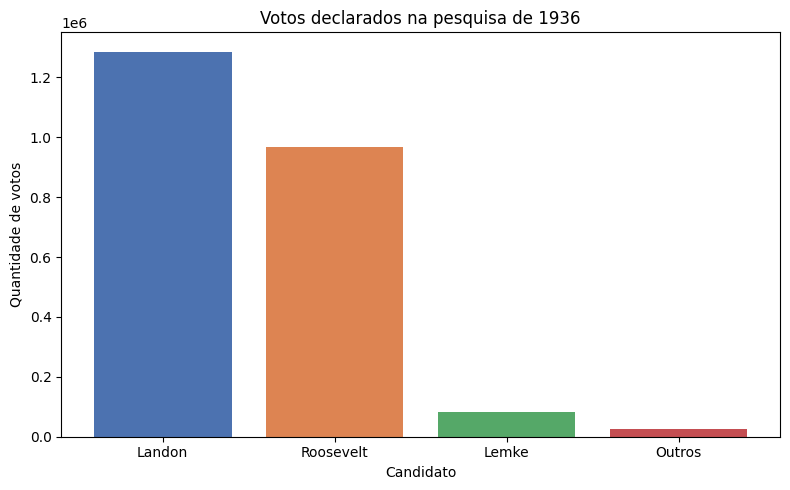

In [ ]:
# Cria a coluna "outros" caso ela ainda não exista
if "outros_poll" not in dados_1936.columns:
    dados_1936["outros_poll"] = (
        dados_1936["total_poll_1936"]
        - dados_1936[["landon_poll", "roosevelt_poll", "lemke_poll"]].sum(axis=1)
    )

# Monta a série com os totais por candidato
votos = pd.DataFrame({
    "Candidato": ["Landon", "Roosevelt", "Lemke", "Outros"],
    "Votos": [
        dados_1936["landon_poll"].sum(),
        dados_1936["roosevelt_poll"].sum(),
        dados_1936["lemke_poll"].sum(),
        dados_1936["outros_poll"].sum()
    ]
})

# Define o tamanho da figura
plt.figure(figsize=(8, 5))

# Cria o gráfico de barras
plt.bar(
    votos["Candidato"],
    votos["Votos"],
    color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
)

# Adiciona título e rótulos
plt.title("Votos declarados na pesquisa de 1936")
plt.xlabel("Candidato")
plt.ylabel("Quantidade de votos")

# Ajusta o layout e mostra
plt.tight_layout()
plt.show()

**Explicação:** Antes de montar o gráfico, somamos os votos de cada candidato. Para a barra “Outros”, pegamos o total de respostas e tiramos os votos de Landon, Roosevelt e Lemke. Fazemos isso para não perder os votos de candidatos menores. O gráfico mostra quantas respostas cada candidato recebeu na pesquisa. Dá para ver que Landon aparecia na frente. Mas, na eleição de verdade, Roosevelt ganhou com folga. Ou seja, o gráfico já mostra o erro histórico: a pesquisa teve muitas respostas, mas elas não representavam bem o eleitorado. Ter muitos dados não é o mesmo que ter dados bons.





### 25. Gráfico dos estados com mais respostas

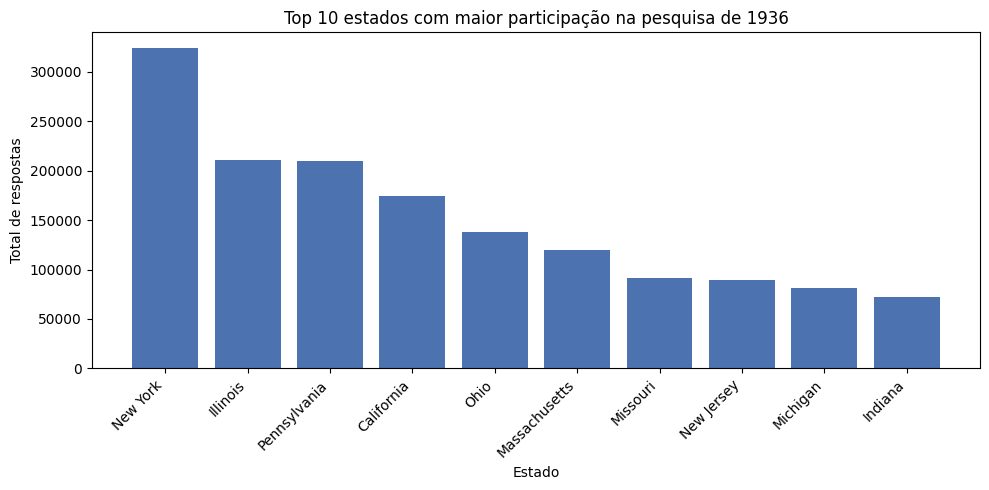

In [ ]:
# Ordena pelos estados com mais respostas e pega os 10 primeiros
top_estados = (
    dados_1936[["state", "total_poll_1936"]]
    .sort_values(by="total_poll_1936", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# Define o tamanho da figura
plt.figure(figsize=(10, 5))

# Cria o gráfico de barras
plt.bar(top_estados["state"], top_estados["total_poll_1936"], color="#4C72B0")

# Título e rótulos
plt.title("Top 10 estados com maior participação na pesquisa de 1936")
plt.xlabel("Estado")
plt.ylabel("Total de respostas")

# Rotaciona os nomes dos estados para não sobrepor
plt.xticks(rotation=45, ha="right")

# Ajusta o layout e mostra
plt.tight_layout()
plt.show()

**Explicação:** Aqui pegamos os 10 estados que mais responderam à pesquisa e colocamos em ordem, do maior para o menor. O gráfico de barras mostra quais estados tiveram mais participação. Estados maiores e mais urbanos costumam aparecer no topo, o que já dá uma pista de que a amostra pode estar concentrada em certos lugares, e não espalhada pelo país. Isso é um sinal de possível viés de amostragem: a pesquisa pode não representar bem todos os eleitores. O rotation=45 só serve para inclinar os nomes dos estados no eixo X e evitar que fiquem sobrepostos.

###26. Indicador de participação estadual

In [ ]:
# Cria um indicador de participação da pesquisa de 1936 por estado.
# Esse indicador mostra quanto cada estado contribuiu para o total de respostas da pesquisa.

participacao_estados = (
    dados_1936[["state", "total_poll_1936"]]
    .sort_values("total_poll_1936", ascending=False)
    .copy()
)

# Calcula a participação percentual de cada estado no total de respostas da pesquisa.
participacao_estados["pct_participacao_amostra"] = (
    participacao_estados["total_poll_1936"]
    / participacao_estados["total_poll_1936"].sum()
) * 100

# Mostra os estados com maior participação.
display(participacao_estados.head(15))

,state,total_poll_1936,pct_participacao_amostra
29,New York,323635,13.701968
10,Illinois,210734,8.921997
35,Pennsylvania,209828,8.883639
3,California,173935,7.364011
32,Ohio,138081,5.846035
18,Massachusetts,119829,5.073287
22,Missouri,91354,3.867720
27,New Jersey,89854,3.804213
19,Michigan,81360,3.444597
11,Indiana,72101,3.052592


**Explicação:** Esta célula calcula quanto cada estado representa dentro do total de respostas da pesquisa de 1936. A variável pct_participacao_amostra permite identificar se as respostas estão distribuídas de maneira equilibrada entre os estados ou se uma parcela importante da amostra está concentrada em poucos estados. Essa concentração pode indicar um possível viés de amostragem, pois a composição da amostra pode não representar igualmente todos os estados.

###27. Concentração da amostra

In [ ]:
# Calcula quanto das respostas da pesquisa está concentrado nos 5 e 10 estados
# com maior número de respostas.

top_5_participacao = participacao_estados.head(5)["pct_participacao_amostra"].sum()
top_10_participacao = participacao_estados.head(10)["pct_participacao_amostra"].sum()

print("CONCENTRAÇÃO DA AMOSTRA DE 1936")
print("—" * 45)
print(f"Participação dos 5 maiores estados : {top_5_participacao:.2f}%")
print(f"Participação dos 10 maiores estados: {top_10_participacao:.2f}%")

CONCENTRAÇÃO DA AMOSTRA DE 1936
—————————————————————————————————————————————
Participação dos 5 maiores estados : 44.72%
Participação dos 10 maiores estados: 63.96%


**Explicação:** Esta célula quantifica a concentração das respostas da pesquisa. Em vez de observar apenas quais estados aparecem no topo, calculamos qual porcentagem de todas as respostas está concentrada nos cinco e dez estados com maior participação. Quanto maior essa concentração, maior a necessidade de verificar se a composição da amostra representa adequadamente a população estudada.

###28. Gráfico do possível viés de amostragem

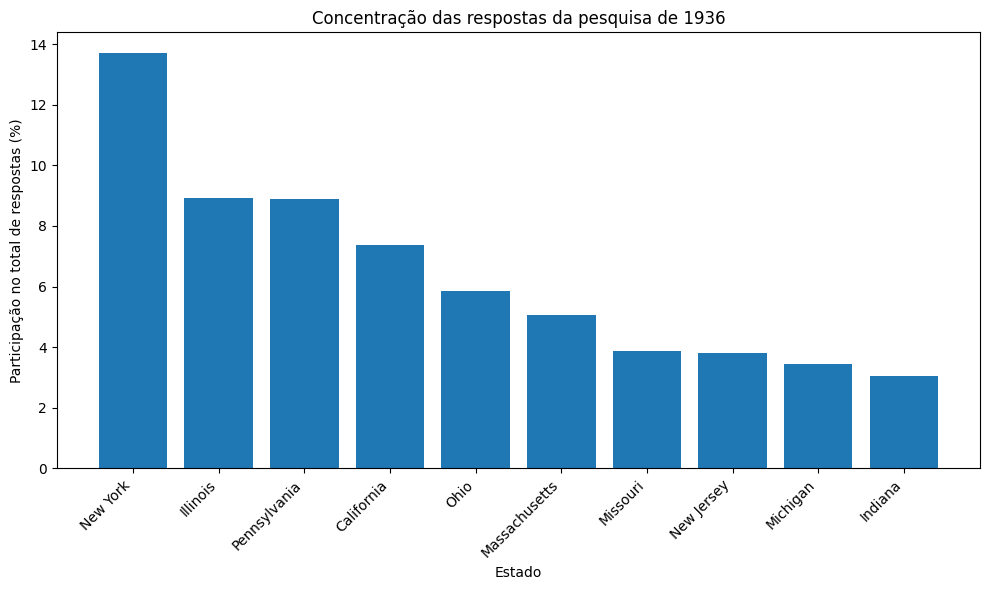

In [ ]:
# Seleciona os 10 estados com maior participação na pesquisa.
top_10_amostra = participacao_estados.head(10)

# Cria o gráfico.
plt.figure(figsize=(10, 6))

plt.bar(
    top_10_amostra["state"],
    top_10_amostra["pct_participacao_amostra"]
)

plt.title("Concentração das respostas da pesquisa de 1936")
plt.xlabel("Estado")
plt.ylabel("Participação no total de respostas (%)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Explicação:** Este gráfico mostra os 10 estados que mais responderam à pesquisa de 1936. As barras indicam quanto cada um representou do total de respostas, em porcentagem. Se poucos estados concentram grande parte das respostas, isso é um alerta: a amostra pode não representar bem o país inteiro. Ou seja, a pesquisa pode ter um viés de amostragem. Esse sinal não prova o erro sozinho, mas deve ser analisado junto com as outras informações dos dados.

### 29. Padronização dos estados para o merge
Para comparar 1932 e 1936, os nomes dos estados precisam estar no mesmo formato.

In [ ]:
# Função que padroniza nomes de estado para comparação
def padronizar_estado(serie):
    return (
        serie.astype(str)
        .str.strip()                        # remove espaços nas pontas
        .str.lower()                        # deixa minúsculo
        .str.replace(".", "", regex=False)  # remove pontos
        .str.replace("  ", " ", regex=False)# remove espaço duplo
    )

# Aplica nas duas bases
dados_1932["state_padrao"] = padronizar_estado(dados_1932["state"])
dados_1936["state_padrao"] = padronizar_estado(dados_1936["state"])

**Explicação:** "N.Y." e "ny" viram o mesmo valor e o merge funciona.

###30. Junção das bases

In [ ]:
# Faz o merge mantendo apenas estados presentes nos dois anos
comparacao = dados_1932.merge(
    dados_1936,
    on="state_padrao",
    how="inner",
    suffixes=("_1932", "_1936")
)

# Mostra quantos estados entraram
print(f"Estados comparados: {len(comparacao)}")
print("\nEstados presentes na comparação:")
print(sorted(comparacao["state_padrao"].unique()))

Estados comparados: 48

Estados presentes na comparação:
['alabama', 'arizona', 'arkansas', 'california', 'colorado', 'connecticut', 'delaware', 'florida', 'georgia', 'idaho', 'illinois', 'indiana', 'iowa', 'kansas', 'kentucky', 'louisiana', 'maine', 'maryland', 'massachusetts', 'michigan', 'minnesota', 'mississippi', 'missouri', 'montana', 'nebraska', 'nevada', 'new hampshire', 'new jersey', 'new mexico', 'new york', 'north carolina', 'north dakota', 'ohio', 'oklahoma', 'oregon', 'pennsylvania', 'rhode island', 'south carolina', 'south dakota', 'tennessee', 'texas', 'utah', 'vermont', 'virginia', 'washington', 'west virginia', 'wisconsin', 'wyoming']


**Explicação:** O how="inner" mantém apenas os estados que aparecem nos dois anos, garantindo comparação justa.

###31. Comparar participação da amostra com comportamento eleitoral de 1932

In [ ]:
# Cria uma tabela para comparar a participação na pesquisa de 1936
# com o comportamento eleitoral registrado em 1932.

comparacao_amostra_1932 = comparacao[
    [
        "state_padrao",
        "total_poll_1936",
        "previous_dem_1932",
        "previous_rep_1932",
        "previous_other_1932",
        "previous_no_vote_1932"
    ]
].copy()

# Calcula a participação percentual de cada estado na pesquisa de 1936.
comparacao_amostra_1932["pct_amostra_1936"] = (
    comparacao_amostra_1932["total_poll_1936"]
    / comparacao_amostra_1932["total_poll_1936"].sum()
) * 100

# Ordena pelos estados com maior participação na amostra.
comparacao_amostra_1932 = comparacao_amostra_1932.sort_values(
    "pct_amostra_1936",
    ascending=False
)

display(comparacao_amostra_1932.head(15))

,state_padrao,total_poll_1936,previous_dem_1932,previous_rep_1932,previous_other_1932,previous_no_vote_1932,pct_amostra_1936
29,new york,323635,12965,129981,110,21397,13.701968
10,illinois,210734,4661,63202,27,8524,8.921997
35,pennsylvania,209828,3699,76264,63,13031,8.883639
3,california,173935,3847,67017,99,10871,7.364011
32,ohio,138081,5096,65536,16,10864,5.846035
18,massachusetts,119829,3700,49229,21,7762,5.073287
22,missouri,91354,2343,32607,16,4105,3.867720
27,new jersey,89854,3510,57340,21,8957,3.804213
19,michigan,81360,1753,41726,28,6221,3.444597
11,indiana,72101,2843,32507,21,4856,3.052592


**Explicação:** Nesta etapa, a participação dos estados na pesquisa de 1936 é comparada com as variáveis eleitorais disponíveis de 1932. A comparação permite verificar se os estados que aparecem com maior peso na amostra também apresentam características eleitorais muito diferentes dos demais estados. Essa análise ajuda a investigar se a composição da amostra pode estar relacionada às diferenças observadas posteriormente entre a pesquisa e o comportamento eleitoral.

###32. Indicador histórico de não participação

In [ ]:
# Calcula um indicador histórico de não participação eleitoral em 1932.

indicador_participacao = comparacao[
    [
        "state_padrao",
        "previous_no_vote_1932",
        "previous_dem_1932",
        "previous_rep_1932",
        "previous_other_1932"
    ]
].copy()

indicador_participacao["total_registros_1932"] = (
    indicador_participacao["previous_no_vote_1932"]
    + indicador_participacao["previous_dem_1932"]
    + indicador_participacao["previous_rep_1932"]
    + indicador_participacao["previous_other_1932"]
)

indicador_participacao["pct_nao_votou_1932"] = (
    indicador_participacao["previous_no_vote_1932"]
    / indicador_participacao["total_registros_1932"]
) * 100

indicador_participacao = indicador_participacao.sort_values(
    "pct_nao_votou_1932",
    ascending=False
)

display(indicador_participacao.head(15))

,state_padrao,previous_no_vote_1932,previous_dem_1932,previous_rep_1932,previous_other_1932,total_registros_1932,pct_nao_votou_1932
37,south carolina,379,392,830,0,1601,23.672705
21,mississippi,198,164,689,0,1051,18.839201
8,georgia,857,499,3465,2,4823,17.769023
15,louisiana,683,831,2489,1,4004,17.057942
7,florida,1475,880,6944,3,9302,15.856805
17,maryland,1990,1137,9723,4,12854,15.481562
16,maine,1760,383,9317,2,11462,15.355086
0,alabama,641,480,3150,1,4272,15.004682
40,texas,2285,1762,11268,2,15317,14.918065
6,delaware,346,229,1809,0,2384,14.513423


**Explicação:** A variável previous_no_vote_1932 representa a quantidade de pessoas que não votaram em 1932. A partir dela é calculada uma proporção de não participação eleitoral histórica para cada estado. Esse indicador não deve ser interpretado como uma taxa direta de não resposta da pesquisa de 1936, pois a base não fornece essa informação. Ele funciona como uma variável histórica de participação que pode ser utilizada para investigar possíveis diferenças na composição dos estados.

###33. Gráfico do indicador de não participação

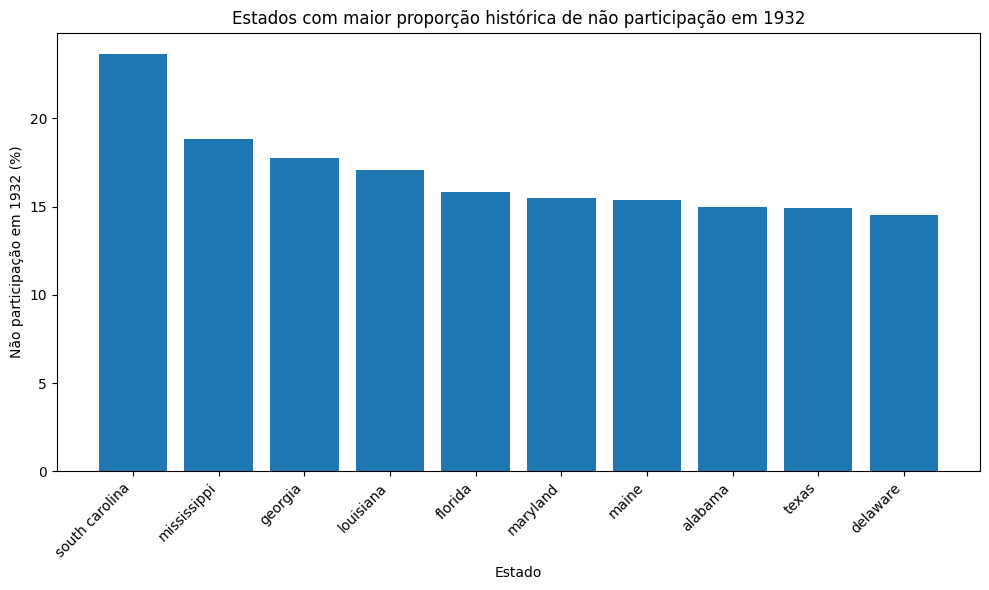

In [ ]:
# Seleciona os 10 estados com maior proporção histórica de não participação em 1932.
top_10_nao_participacao = indicador_participacao.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_nao_participacao["state_padrao"],
    top_10_nao_participacao["pct_nao_votou_1932"]
)

plt.title("Estados com maior proporção histórica de não participação em 1932")
plt.xlabel("Estado")
plt.ylabel("Não participação em 1932 (%)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Explicação:** Este gráfico mostra os estados que, em 1932, tinham a maior proporção de pessoas que não votaram. Ele serve como uma pista indireta: se em um estado muita gente já não votava antes, talvez esse estado também tenha respondido menos à pesquisa de 1936. Mas a base não diz quem deixou de responder à pesquisa. Então, este gráfico não mede diretamente a não resposta. Ele só ajuda a levantar suspeitas e deve ser lido junto com os outros dados.

### 34. Cálculo das proporções por estado
Para comparar estados de tamanhos diferentes, precisamos trabalhar com percentuais em vez de números absolutos.

In [ ]:
# Substitui 0 por NaN para evitar divisão por zero
total_valido = dados_1936["total_poll_1936"].replace(0, np.nan)

# Calcula o percentual de cada candidato em cada estado
dados_1936["pct_landon"] = (
    dados_1936["landon_poll"] / total_valido
) * 100

dados_1936["pct_roosevelt"] = (
    dados_1936["roosevelt_poll"] / total_valido
) * 100

dados_1936["pct_lemke"] = (
    dados_1936["lemke_poll"] / total_valido
) * 100

# Mostra uma amostra do resultado
display(
    dados_1936[
        ["state", "pct_landon", "pct_roosevelt", "pct_lemke"]
    ].head()
)

,state,pct_landon,pct_roosevelt,pct_lemke
0,Alabama,23.054321,75.958713,0.512318
1,Arizona,52.211796,44.124218,2.323503
2,Arkansas,25.844402,72.182163,1.309298
3,California,51.465203,44.410268,2.861414
4,Colorado,59.542298,37.426267,2.161577


**Explicação:** O replace(0, np.nan) evita divisão por zero em estados sem respostas.

### 35. Estados mais favoráveis a cada candidato
Vamos ranquear os estados que mais apoiaram Roosevelt e Landon.

In [ ]:
# Top 10 estados pró-Landon
top_landon = (
    dados_1936[["state", "pct_landon"]]
    .sort_values(by="pct_landon", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# Top 10 estados pró-Roosevelt
top_roosevelt = (
    dados_1936[["state", "pct_roosevelt"]]
    .sort_values(by="pct_roosevelt", ascending=False)
    .head(11)
    .reset_index(drop=True)
)

# Mostra os dois rankings
display(top_landon)
display(top_roosevelt)

,state,pct_landon
0,New Hampshire,74.238026
1,Massachusetts,72.978161
2,Vermont,72.876409
3,Rhode Island,70.191659
4,Maine,66.807010
5,New Jersey,65.302602
6,Connecticut,65.251070
7,Michigan,63.271878
8,Kansas,62.259108
9,South Dakota,61.213739


,state,pct_roosevelt
0,Mississippi,86.708500
1,South Carolina,84.322336
2,Georgia,75.975057
3,Alabama,75.958713
4,North Carolina,72.252468
5,Arkansas,72.182163
6,Texas,69.774495
7,Tennessee,66.145173
8,Louisiana,62.789035
9,Virginia,61.548335


**Explicação:** Isso mostra o mapa político da pesquisa: onde cada candidato era mais forte.

### 36. Gráfico comparativo com escala igual
Colocar os dois gráficos lado a lado com a mesma escala ajuda a comparar.

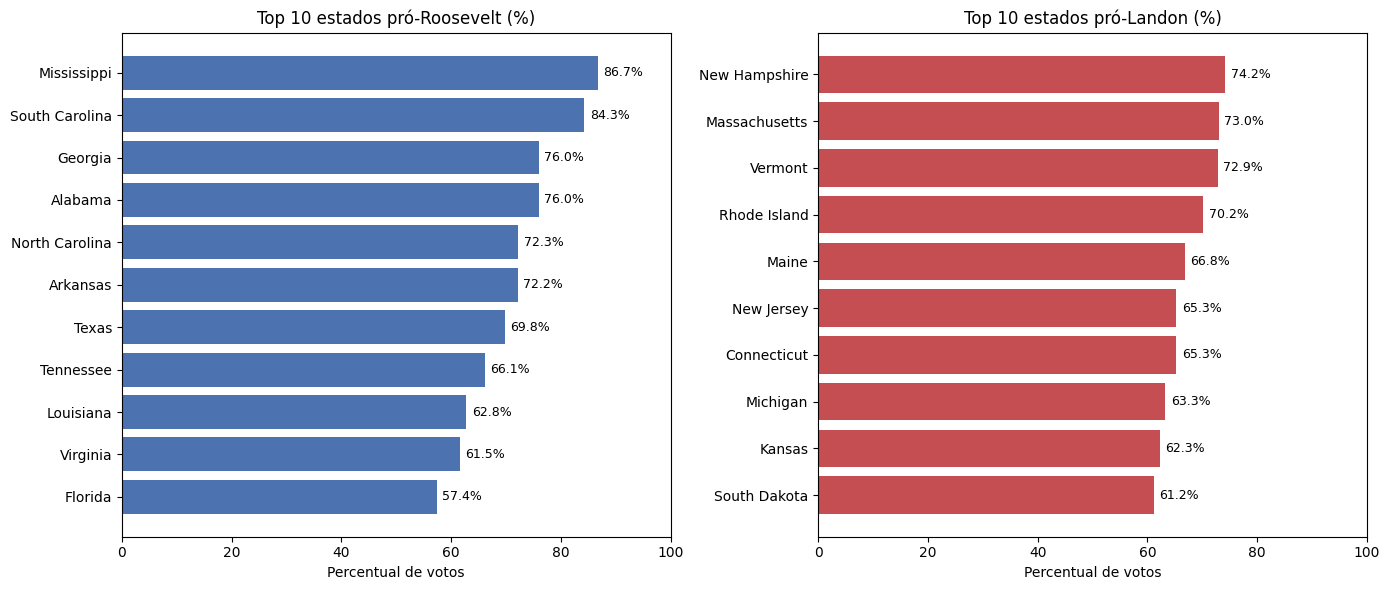

In [ ]:
# Cria dois gráficos lado a lado com o mesmo eixo X
fig, eixos = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# --- Gráfico Roosevelt ---
eixos[0].barh(top_roosevelt["state"], top_roosevelt["pct_roosevelt"], color="#4C72B0")
eixos[0].set_title("Top 10 estados pró-Roosevelt (%)")
eixos[0].set_xlabel("Percentual de votos")
eixos[0].invert_yaxis()
eixos[0].set_xlim(0, 100)

# Anota os valores ao lado das barras
for i, v in enumerate(top_roosevelt["pct_roosevelt"]):
    eixos[0].text(v + 1, i, f"{v:.1f}%", va='center', fontsize=9)

# --- Gráfico Landon ---
eixos[1].barh(top_landon["state"], top_landon["pct_landon"], color="#C44E52")
eixos[1].set_title("Top 10 estados pró-Landon (%)")
eixos[1].set_xlabel("Percentual de votos")
eixos[1].invert_yaxis()
eixos[1].set_xlim(0, 100)

# Anota os valores ao lado das barras
for i, v in enumerate(top_landon["pct_landon"]):
    eixos[1].text(v + 1, i, f"{v:.1f}%", va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Explicação:** Este gráfico compara os estados onde Roosevelt e Landon tiveram os maiores percentuais de voto na pesquisa. São dois gráficos de barras lado a lado: um para Roosevelt e outro para Landon. Os nomes dos estados ficam no eixo vertical, e o percentual de votos no eixo horizontal. Os dois usam a mesma escala, de 0 a 100%, para que a comparação seja justa. Os valores exatos aparecem ao lado de cada barra. Assim, dá para ver rapidamente em quais estados cada candidato era mais forte e como o apoio se distribuía pelo país. É como um mapa político da pesquisa, mostra onde cada um tinha mais força, mesmo que o resultado geral da amostra apontasse vantagem para Landon.

### 37. Diferenças entre 1932 e 1936
Comparar os votos de 1932 com os da pesquisa de 1936 por estado.

In [ ]:
# Diferença republicana (1932 menos 1936)
comparacao["dif_rep"] = comparacao["previous_rep_1932"] - comparacao["landon_poll"]

# Diferença democrata (1932 menos 1936)
comparacao["dif_dem"] = comparacao["previous_dem_1932"] - comparacao["roosevelt_poll"]

# Mostra as primeiras linhas
display(
    comparacao[
        ["state_padrao", "previous_rep_1932", "landon_poll", "dif_rep",
         "previous_dem_1932", "roosevelt_poll", "dif_dem"]
    ].head(10)
)

,state_padrao,previous_rep_1932,landon_poll,dif_rep,previous_dem_1932,roosevelt_poll,dif_dem
0,alabama,3150,3060,90,480,10082,-9602
1,arizona,2022,2337,-315,218,1975,-1757
2,arkansas,2997,2724,273,250,7608,-7358
3,california,67017,89516,-22499,3847,77245,-73398
4,colorado,9870,15949,-6079,603,10025,-9422
5,connecticut,21590,28809,-7219,1539,13413,-11874
6,delaware,1809,2918,-1109,229,2048,-1819
7,florida,6944,6087,857,880,8620,-7740
8,georgia,3465,3948,-483,499,12915,-12416
9,idaho,2649,3653,-1004,211,2611,-2400


**Explicação:** A diferença mostra quanto cada candidato ganhou ou perdeu em relação ao desempenho do partido na eleição anterior.

### 38. Dispersão 1932 vs 1936

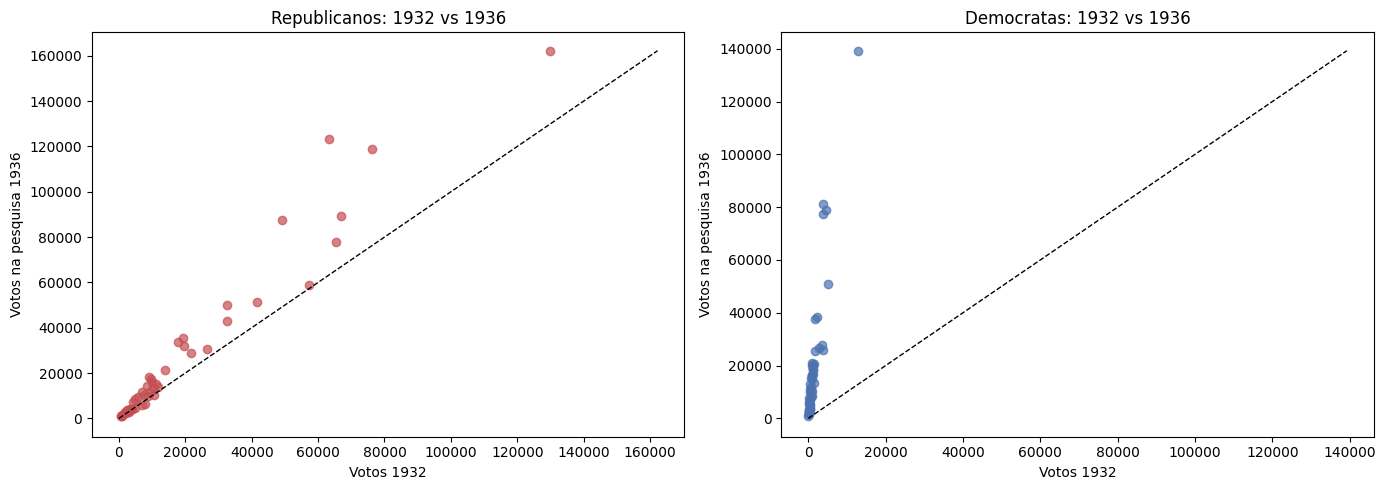

In [ ]:
# Cria dois gráficos lado a lado
fig, eixos = plt.subplots(1, 2, figsize=(14, 5))

# --- Republicanos ---
eixos[0].scatter(comparacao["previous_rep_1932"], comparacao["landon_poll"],
                 color="#C44E52", alpha=0.7)
max_rep = max(comparacao["previous_rep_1932"].max(), comparacao["landon_poll"].max())
eixos[0].plot([0, max_rep], [0, max_rep], color="black", linestyle="--", linewidth=1)
eixos[0].set_title("Republicanos: 1932 vs 1936")
eixos[0].set_xlabel("Votos 1932")
eixos[0].set_ylabel("Votos na pesquisa 1936")

# --- Democratas ---
eixos[1].scatter(comparacao["previous_dem_1932"], comparacao["roosevelt_poll"],
                 color="#4C72B0", alpha=0.7)
max_dem = max(comparacao["previous_dem_1932"].max(), comparacao["roosevelt_poll"].max())
eixos[1].plot([0, max_dem], [0, max_dem], color="black", linestyle="--", linewidth=1)
eixos[1].set_title("Democratas: 1932 vs 1936")
eixos[1].set_xlabel("Votos 1932")
eixos[1].set_ylabel("Votos na pesquisa 1936")

plt.tight_layout()
plt.show()

**Explicação:** Aqui temos dois gráficos de dispersão lado a lado, um para os republicanos e outro para os democratas. Cada pontinho representa um estado. No eixo X estão os votos de 1932; no eixo Y, os votos na pesquisa de 1936. A linha tracejada é a referência de igualdade (y = x): se o ponto estiver em cima dela, o estado teve a mesma quantidade de votos nos dois anos. Se o ponto estiver acima da linha, significa que em 1936 houve mais votos que em 1932. Se estiver abaixo, houve menos votos em 1936. Assim, dá para ver se a pesquisa de 1936 acompanha o comportamento eleitoral de 1932. Quando os pontos ficam próximos da linha, a relação entre os dois anos é forte. Quando ficam espalhados, a relação é mais fraca.

### 39. Correlação entre as variáveis

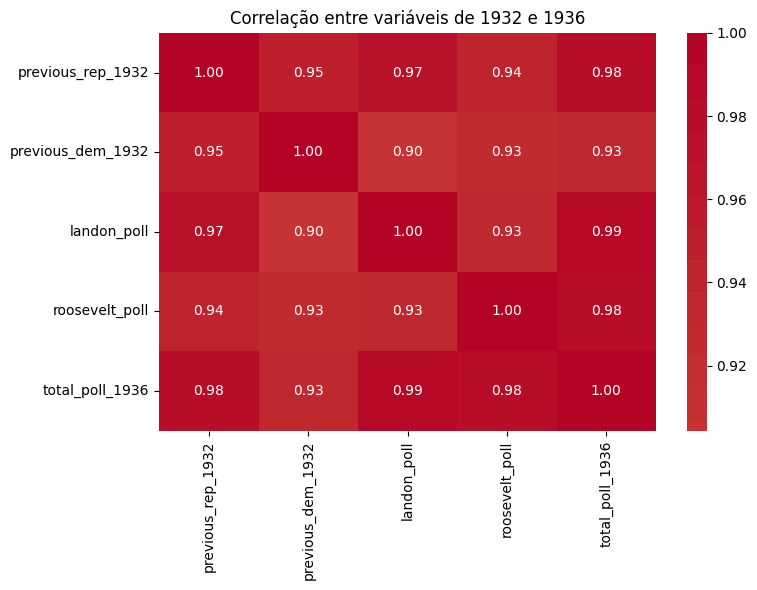

In [ ]:
# Colunas que vão para a matriz de correlação
colunas_corr = [
    "previous_rep_1932", "previous_dem_1932",
    "landon_poll", "roosevelt_poll", "total_poll_1936"
]

# Mantém só as que existem
colunas_corr = [c for c in colunas_corr if c in comparacao.columns]

# Calcula a matriz de correlação
correlacao = comparacao[colunas_corr].corr()

# Cria o heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlação entre variáveis de 1932 e 1936")
plt.tight_layout()
plt.show()

**Explicação:** Este gráfico é um mapa de calor que mostra a correlação entre as variáveis de 1932 e 1936. Correlação é o quanto duas coisas caminham juntas. Os números vão de -1 a 1. Perto de 1 significa relação forte positiva: quando uma sobe, a outra também sobe. Perto de -1 significa relação negativa: quando uma sobe, a outra desce. Perto de 0 significa pouca relação. As cores ajudam a ler: tons mais quentes indicam correlação positiva, tons mais frios indicam correlação negativa. No caso, as correlações são muito altas: 0,93 entre Roosevelt 1936 e os democratas de 1932, e 0,97 entre Landon 1936 e os republicanos de 1932. Isso mostra que o comportamento eleitoral de 1932 e a pesquisa de 1936 caminharam juntos, onde um partido ia bem antes, o candidato correspondente também aparecia bem na pesquisa. Mas isso não garante que a amostra representava o país inteiro; apenas indica que havia continuidade eleitoral entre os dois anos.

### 40. Boxplot das proporções por candidato

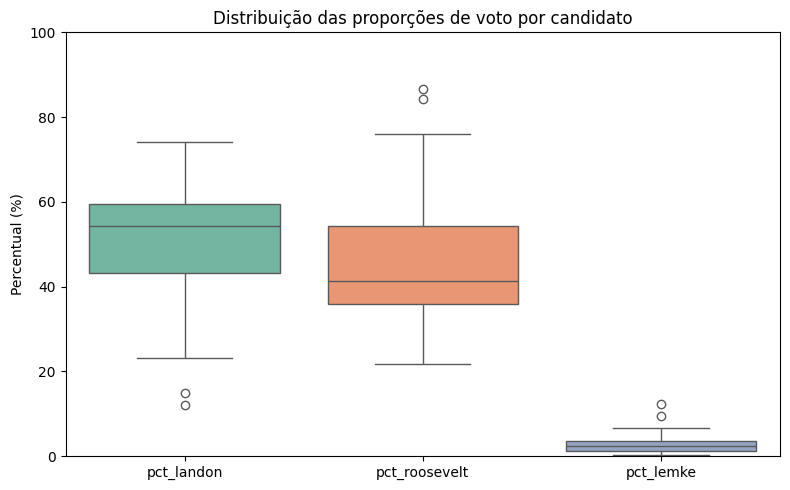

In [ ]:
# Define o tamanho da figura
plt.figure(figsize=(8, 5))

# Cria o boxplot das proporções
sns.boxplot(
    data=dados_1936[["pct_landon", "pct_roosevelt", "pct_lemke"]],
    palette="Set2"
)

# Título e rótulos
plt.title("Distribuição das proporções de voto por candidato")
plt.ylabel("Percentual (%)")
plt.ylim(0, 100)

# Ajusta e mostra
plt.tight_layout()
plt.show()

**Explicação:** O boxplot mostra como os percentuais de voto de cada candidato se distribuem entre os estados. A linha no meio da caixa é a mediana: metade dos estados ficou abaixo dela, metade acima. A caixa mostra onde estão os 50% do meio dos estados. As linhas para cima e para baixo mostram até onde vão os valores normais. Os pontinhos fora delas são outliers, ou seja, estados muito diferentes dos demais. Comparando as caixas, dá para ver se o apoio a um candidato é mais espalhado ou mais concentrado. Assim, é uma forma rápida de comparar a distribuição dos votos de Landon, Roosevelt e Lemke entre os estados.

### 41. Histogramas das proporções

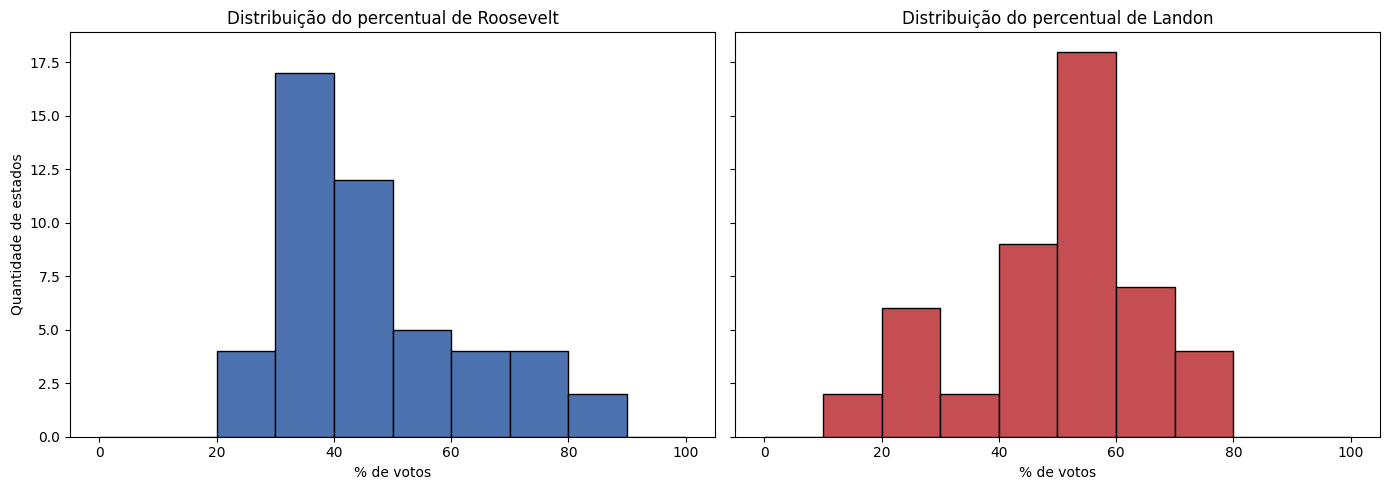

In [ ]:
# Cria dois histogramas lado a lado com o mesmo eixo X
fig, eixos = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

# Define faixas fixas para os dois gráficos (0 a 100, passos de 10)
faixas = range(0, 101, 10)

#Roosevelt
eixos[0].hist(dados_1936["pct_roosevelt"].dropna(), bins=faixas,
              color="#4C72B0", edgecolor="black")
eixos[0].set_title("Distribuição do percentual de Roosevelt")
eixos[0].set_xlabel("% de votos")
eixos[0].set_ylabel("Quantidade de estados")

#Landon
eixos[1].hist(dados_1936["pct_landon"].dropna(), bins=faixas,
              color="#C44E52", edgecolor="black")
eixos[1].set_title("Distribuição do percentual de Landon")
eixos[1].set_xlabel("% de votos")

plt.tight_layout()
plt.show()

**Explicação:** Aqui temos dois histogramas lado a lado: um mostra os percentuais de Roosevelt e o outro os de Landon. Cada barrinha representa uma faixa de porcentagem. A altura da barra diz quantos estados caíram naquela faixa. Os dois gráficos usam a mesma escala no eixo X (0 a 100%) e a mesma escala no eixo Y, para que a comparação seja justa. Assim, dá para ver rapidamente se o apoio a um candidato está mais concentrado em percentuais baixos, médios ou altos, e comparar a distribuição dos votos entre Roosevelt e Landon.

### 42. Estados mais disputados
Quais estados tiveram margem pequena entre os dois candidatos?

In [ ]:
# Calcula a margem de diferença entre Roosevelt e Landon
dados_1936["margem"] = abs(dados_1936["pct_roosevelt"] - dados_1936["pct_landon"])

# Ordena do menor para o maior (mais disputados primeiro)
mais_disputados = (
    dados_1936[["state", "pct_roosevelt", "pct_landon", "margem"]]
    .sort_values("margem", ascending=True)
    .head(10)
    .reset_index(drop=True)
)

# Mostra a tabela
display(mais_disputados)

,state,pct_roosevelt,pct_landon,margem
0,New Mexico,49.420161,48.319952,1.100208
1,Oklahoma,50.298622,48.186580,2.112042
2,Nevada,47.441629,49.826130,2.384501
3,Maryland,50.008180,47.614244,2.393936
4,Oregon,46.277045,49.640805,3.363759
5,North Dakota,40.223831,46.631556,6.407724
6,California,44.410268,51.465203,7.054934
7,New York,43.035209,50.136728,7.101519
8,Arizona,44.124218,52.211796,8.087578
9,Kentucky,53.763650,43.307087,10.456563


**Explicação:** Margem pequena indica disputa acirrada. Esses estados são os mais difíceis de prever.

### 43. Estados com maior vantagem

In [ ]:
# Ordena do maior para o menor (mais desequilibrados primeiro)
mais_desequilibrados = (
    dados_1936[["state", "margem"]]
    .sort_values("margem", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# Mostra a tabela
display(mais_desequilibrados)

,state,margem
0,Mississippi,74.614946
1,South Carolina,69.522905
2,Alabama,52.904392
3,Georgia,52.750162
4,New Hampshire,52.169005
5,Massachusetts,51.309783
6,Vermont,48.138084
7,Rhode Island,46.645971
8,Arkansas,46.337761
9,North Carolina,45.195415


**Explicação:** No outro extremo, margens grandes indicam estados onde o resultado era praticamente certo.

### 44. Ranking dos estados (Top 15 Roosevelt)

In [ ]:
# Ordena os estados pelo percentual de Roosevelt
ranking = (
    dados_1936[["state", "pct_roosevelt", "pct_landon"]]
    .sort_values(by="pct_roosevelt", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

# Mostra a tabela
display(ranking)

,state,pct_roosevelt,pct_landon
0,Mississippi,86.708500,12.093554
1,South Carolina,84.322336,14.799430
2,Georgia,75.975057,23.224896
3,Alabama,75.958713,23.054321
4,North Carolina,72.252468,27.057053
5,Arkansas,72.182163,25.844402
6,Texas,69.774495,28.543520
7,Tennessee,66.145173,32.967510
8,Louisiana,62.789035,29.288836
9,Virginia,61.548335,37.490832


**Explicação:** Um ranking simples para visualizar rapidamente onde Roosevelt tinha mais apoio.

### 45. Matriz de dispersão (pairplot)

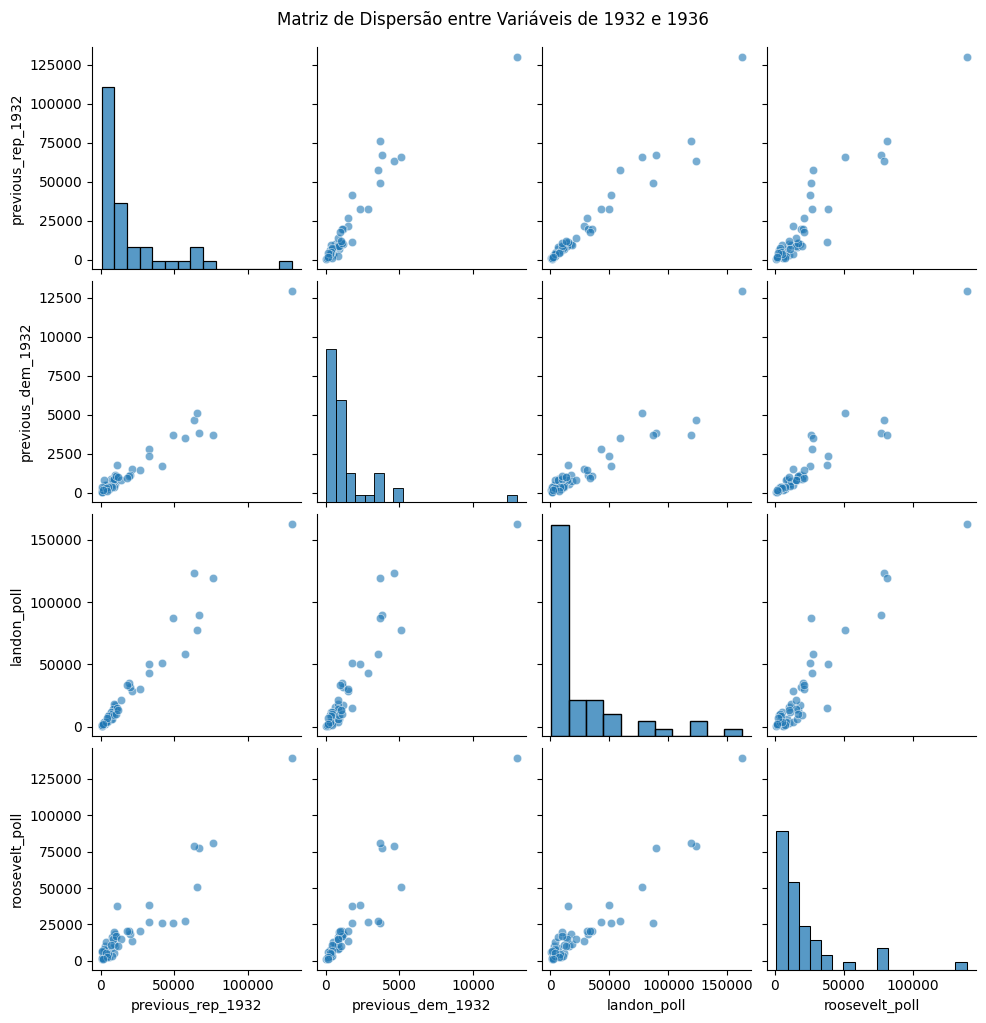

In [ ]:
# Colunas que vão para o pairplot
colunas_pairplot = [
    "previous_rep_1932", "previous_dem_1932",
    "landon_poll", "roosevelt_poll"
]

# Mantém só as que existem
colunas_pairplot = [c for c in colunas_pairplot if c in comparacao.columns]

# Cria o pairplot
sns.pairplot(
    comparacao[colunas_pairplot].dropna(),
    diag_kind="hist",
    plot_kws={"alpha": 0.6}
)

plt.suptitle("Matriz de Dispersão entre Variáveis de 1932 e 1936", y=1.02)
plt.show()

**Explicação:** Este gráfico é uma matriz de dispersão (pairplot). Ele pega todas as variáveis escolhidas e compara uma contra a outra, duas a duas. Cada quadradinho mostra a relação entre um par de variáveis: cada pontinho é um estado. Quando os pontos formam uma nuvem mais alinhada, isso indica que as duas variáveis caminham juntas. Quando ficam espalhados, a relação é mais fraca. Na diagonal, em vez de dispersão, aparecem histogramas, que mostram como cada variável se distribui sozinha. No conjunto, o pairplot dá uma visão geral rápida das relações entre os votos de 1932 e a pesquisa de 1936, ajudando a ver se os padrões são consistentes ou se há estados fora do padrão.

### 46. Resumo da análise exploratória

In [ ]:
# Mostra um resumo com os principais indicadores
print("RESUMO DA ANÁLISE EXPLORATÓRIA")
print("—" * 45)
print(f"Estados comparados entre 1932 e 1936 : {len(comparacao)}")
print(f"Total de votos declarados em 1936    : {int(dados_1936['total_poll_1936'].sum()):,}")
print(f"Estado com mais respostas            : {dados_1936.loc[dados_1936['total_poll_1936'].idxmax(), 'state']}")
print(f"Estado com menos respostas           : {dados_1936.loc[dados_1936['total_poll_1936'].idxmin(), 'state']}")
print(f"Correlação Roosevelt 1936 vs Dem 1932: {correlacao.loc['roosevelt_poll', 'previous_dem_1932']:.2f}")
print(f"Correlação Landon 1936 vs Rep 1932   : {correlacao.loc['landon_poll', 'previous_rep_1932']:.2f}")

RESUMO DA ANÁLISE EXPLORATÓRIA
—————————————————————————————————————————————
Estados comparados entre 1932 e 1936 : 48
Total de votos declarados em 1936    : 2,361,960
Estado com mais respostas            : New York
Estado com menos respostas           : Nevada
Correlação Roosevelt 1936 vs Dem 1932: 0.93
Correlação Landon 1936 vs Rep 1932   : 0.97


**Explicação:** Este bloco reúne os principais indicadores em um só lugar, fechando a análise com uma visão consolidada.

## Conclusão da Análise
Nesta etapa, foi realizada a análise exploratória dos dados da pesquisa da Literary Digest de 1936. Foram examinadas as estatísticas descritivas das variáveis eleitorais, a distribuição de votos entre os candidatos, a participação dos estados e as proporções de voto por candidato em cada estado.

Em seguida, os dados de 1936 foram comparados com os resultados eleitorais de 1932 por meio de um merge entre as duas bases. Essa comparação permitiu observar diferenças no comportamento eleitoral entre os dois anos, além de correlações entre as variáveis de cada período.

Os resultados mostram diferenças importantes na distribuição dos votos entre os estados, além de variações no nível de participação da pesquisa. A comparação com os dados de 1932 permite observar mudanças no comportamento eleitoral e fornece uma base para investigar as possíveis causas do erro histórico da Literary Digest.

## Treinamento do modelo de regressão

Nessa etapa vamos treinar o modelo de regressão, testar o modelo, ajustar parâmetros e calcular as métricas de erros.

### 47. Treinamento do modelo de regressão

In [ ]:
variaveis_modelo = [
    "previous_dem_1932",
    "previous_rep_1932",
    "previous_other_1932",
    "previous_no_vote_1932",
    "electoral_votes_1936"
]

# Garante que pct_roosevelt existe em comparacao
if "pct_roosevelt" not in comparacao.columns:
    comparacao["pct_roosevelt"] = (
        comparacao["roosevelt_poll"] / comparacao["total_poll_1936"]
    ) * 100

dados_modelo = comparacao[
    variaveis_modelo + ["pct_roosevelt"]
].dropna().copy()

print("BASE PARA O MODELO")
print("—" * 45)
print("Registros:", len(dados_modelo))
print("Variáveis de entrada:", len(variaveis_modelo))
print()

print(dados_modelo.head())

BASE PARA O MODELO
—————————————————————————————————————————————
Registros: 48
Variáveis de entrada: 5

   previous_dem_1932  previous_rep_1932  previous_other_1932  \
0                480               3150                    1   
1                218               2022                    1   
2                250               2997                    1   
3               3847              67017                   99   
4                603               9870                    4   

   previous_no_vote_1932  electoral_votes_1936  pct_roosevelt  
0                    641                    11      75.958713  
1                    333                     3      44.124218  
2                    464                     9      72.182163  
3                  10871                    22      44.410268  
4                   1473                     6      37.426267  


**Explicação:** Selecionamos as variáveis históricas que serão usadas para prever o percentual de Roosevelt.

### 48. Separar X e y

In [ ]:
# Variáveis de entrada
X = comparacao[variaveis_modelo]

# Variável que queremos prever
y = comparacao["pct_roosevelt"]

print("Variáveis de entrada (X):")
print(X.columns.tolist())

print("\nVariável alvo (y):")
print(y.name)

Variáveis de entrada (X):
['previous_dem_1932', 'previous_rep_1932', 'previous_other_1932', 'previous_no_vote_1932', 'electoral_votes_1936']

Variável alvo (y):
pct_roosevelt


**Explicação:** Agora separamos os dados em:

X = informações usadas pelo modelo

y = aquilo que queremos prever

X contém as informações das eleições de 1932, serão utilizadas pelo modelo para fazer a previsão. y contém o percentual de votos de Roosevelt, que é o valor que queremos prever.

### 49. Dividir treino e teste

In [ ]:
# Cria o modelo de Regressão Linear
from sklearn.model_selection import train_test_split

# Divide os dados em treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("DIVISÃO DOS DADOS")
print("—" * 35)
print(f"Treinamento: {len(X_train)} registros")
print(f"Teste      : {len(X_test)} registros")

DIVISÃO DOS DADOS
———————————————————————————————————
Treinamento: 38 registros
Teste      : 10 registros


**Explicação:** Os dados são divididos em treinamento e teste. O modelo aprende com os dados de treinamento e depois é avaliado usando dados que não foram utilizados durante o treinamento.

### 50. Treinar o modelo de regressão

In [ ]:
# Cria o modelo de Regressão Linear
from sklearn.linear_model import LinearRegression

# Cria o modelo
modelo = LinearRegression()

# Treina o modelo com os dados de treinamento
modelo.fit(X_train, y_train)

print("Modelo de regressão linear treinado com sucesso.")

Modelo de regressão linear treinado com sucesso.


**Explicação:** A regressão linear aprende a relação entre os dados históricos de 1932 e o percentual de Roosevelt observado na pesquisa de 1936.

### 51. Previsões

In [ ]:
# Faz previsões usando os dados de teste
y_pred = modelo.predict(X_test)

# Mostra algumas previsões
resultado = pd.DataFrame({
    "Real": y_test.values,
    "Previsto": y_pred
})

display(resultado)

,Real,Previsto
0,30.750996,-2.304052
1,69.774495,104.732977
2,22.069021,37.143717
3,61.548335,62.348975
4,37.879763,45.295311
5,84.322336,63.571138
6,34.686842,41.527491
7,31.570796,33.732926
8,37.426267,39.298103
9,47.441629,46.328956


**Explicação:** Essa parte nos permite fazer uma primeira avaliação visual do desempenho do modelo. Ao comparar os valores reais com os previstos, percebemos que algumas previsões ficaram próximas dos resultados reais, enquanto outras apresentaram diferenças grandes, como previsões abaixo de 0% ou acima de 100%. Isso indica que o modelo apresenta erros consideráveis e limitações para representar todos os resultados, justificando a necessidade de calcular as métricas MAE, MSE, RMSE e R² para medir seu desempenho de forma quantitativa.

### 52. Calcular as métricas de erro

In [ ]:
# Métricas utilizadas para avaliar o desempenho do modelo: MAE, MSE e R².
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calcula as métricas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MÉTRICAS DA REGRESSÃO LINEAR")
print("—" * 40)
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")

MÉTRICAS DA REGRESSÃO LINEAR
————————————————————————————————————————
MAE  : 12.40
MSE  : 308.44
RMSE : 17.56
R²   : 0.13


**Explicação:** O MAE (Erro Absoluto Médio) indica, em média, quantos pontos percentuais as previsões se afastaram dos valores reais. O MSE (Erro Quadrático Médio) também mede os erros, mas atribui maior peso aos erros de maior magnitude. Já o RMSE (Raiz do Erro Quadrático Médio) permite interpretar esses erros na mesma unidade dos dados, facilitando a compreensão da magnitude das previsões. Por fim, o R² (Coeficiente de Determinação) indica a proporção da variação dos dados que é explicada pelo modelo.

###53. Preparar a previsão como referência histórica

In [ ]:
# Cria uma cópia dos dados utilizados no modelo.
# A previsão da regressão será interpretada como uma estimativa baseada
# no comportamento eleitoral observado em 1932.

analise_correcao = dados_modelo.copy()

# Gera a previsão para todos os estados da base.
analise_correcao["previsao_modelo_1936"] = modelo.predict(
    analise_correcao[variaveis_modelo]
)

# Calcula a diferença entre a previsão baseada em 1932
# e o percentual observado na pesquisa de 1936.

analise_correcao["diferenca_modelo_pesquisa"] = (
    analise_correcao["previsao_modelo_1936"]
    - analise_correcao["pct_roosevelt"]
)

display(
    analise_correcao[
        [
            "pct_roosevelt",
            "previsao_modelo_1936",
            "diferenca_modelo_pesquisa"
        ]
    ].head(10)
)

,pct_roosevelt,previsao_modelo_1936,diferenca_modelo_pesquisa
0,75.958713,70.179873,-5.778840
1,44.124218,41.968858,-2.155360
2,72.182163,61.672922,-10.509242
3,44.410268,31.785376,-12.624893
4,37.426267,39.298103,1.871836
5,30.379833,28.993605,-1.386228
6,40.731901,42.169152,1.437251
7,57.386326,51.164406,-6.221920
8,75.975057,73.861407,-2.113650
9,39.886954,44.951645,5.064692


**Explicação:** Nesta etapa, o modelo treinado anteriormente é aplicado a todos os estados da base. A variável previsao_modelo_1936 representa uma estimativa do percentual de Roosevelt baseada nas características eleitorais de 1932 e nas demais variáveis utilizadas no modelo. A diferença entre essa estimativa e o percentual observado na pesquisa de 1936 permite identificar estados nos quais a pesquisa se distancia mais da referência construída pelo modelo.

###54. Identificar os maiores desvios

In [ ]:
# Ordena os estados pelo tamanho absoluto da diferença entre
# a pesquisa de 1936 e a previsão baseada nas informações de 1932.

maiores_desvios = analise_correcao.copy()

maiores_desvios["desvio_absoluto"] = (
    maiores_desvios["diferenca_modelo_pesquisa"].abs()
)

maiores_desvios = maiores_desvios.sort_values(
    "desvio_absoluto",
    ascending=False
)

display(
    maiores_desvios[
        [
            "pct_roosevelt",
            "previsao_modelo_1936",
            "diferenca_modelo_pesquisa",
            "desvio_absoluto"
        ]
    ].head(10)
)

,pct_roosevelt,previsao_modelo_1936,diferenca_modelo_pesquisa,desvio_absoluto
40,69.774495,104.732977,34.958482,34.958482
27,30.750996,-2.304052,-33.055048,33.055048
21,86.708500,65.861024,-20.847475,20.847475
37,84.322336,63.571138,-20.751198,20.751198
46,35.116090,52.583451,17.467361,17.467361
26,22.069021,37.143717,15.074695,15.074695
33,50.298622,64.143064,13.844442,13.844442
3,44.410268,31.785376,-12.624893,12.624893
42,24.738325,37.025134,12.286809,12.286809
32,36.774067,24.729097,-12.044970,12.044970


**Explicação:** Esta célula identifica os estados em que existe maior diferença entre o percentual observado na pesquisa e a estimativa baseada no comportamento eleitoral histórico. O objetivo é localizar onde a pesquisa apresenta maior divergência em relação à referência produzida pelo modelo.

###55. Visualização da diferença

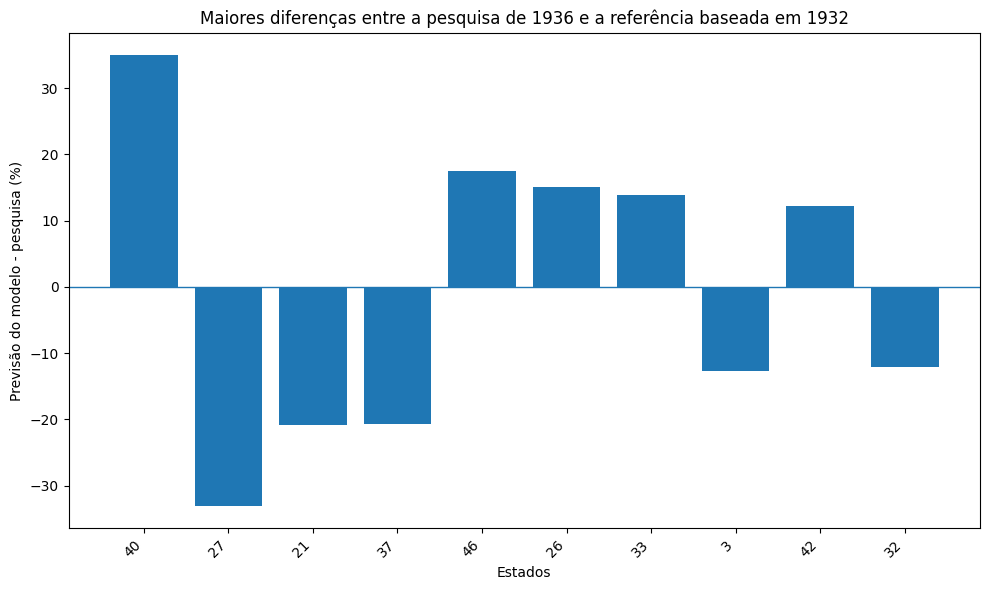

In [ ]:
# Seleciona os 10 estados com maior diferença absoluta.
top_10_desvios = maiores_desvios.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    range(len(top_10_desvios)),
    top_10_desvios["diferenca_modelo_pesquisa"]
)

plt.axhline(0, linewidth=1)

plt.title(
    "Maiores diferenças entre a pesquisa de 1936 e a referência baseada em 1932"
)

plt.xlabel("Estados")
plt.ylabel("Previsão do modelo - pesquisa (%)")

plt.xticks(
    range(len(top_10_desvios)),
    top_10_desvios.index,
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

**Explicação:** O gráfico apresenta os estados com maiores diferenças entre a previsão baseada no comportamento eleitoral de 1932 e os percentuais observados na pesquisa de 1936. Valores positivos indicam que a previsão do modelo ficou acima do percentual observado na pesquisa, enquanto valores negativos indicam que ficou abaixo.

### 56. Coeficientes da regressão

In [ ]:
# Cria uma tabela com os coeficientes
coeficientes = pd.DataFrame({
    "Variável": X.columns,
    "Coeficiente": modelo.coef_
})

display(coeficientes)

print(f"Intercepto: {modelo.intercept_:.2f}")

,Variável,Coeficiente
0,previous_dem_1932,0.006082
1,previous_rep_1932,-0.002380
2,previous_other_1932,0.392690
3,previous_no_vote_1932,0.001466
4,electoral_votes_1936,3.606368


Intercepto: 33.76


**Explicação:** Os coeficientes indicam como cada variável está relacionada com a previsão do percentual de Roosevelt, mantendo as demais variáveis constantes.

### 57. Ajustar parâmetros

In [ ]:
# Usado para criar o modelo de Regressão Ridge
from sklearn.linear_model import Ridge

# Testa diferentes combinações de parâmetros para encontrar a melhor configuração do modelo.
from sklearn.model_selection import GridSearchCV

# Cria o modelo Ridge
modelo_ridge = Ridge()

# Define os valores de alpha que serão testados
parametros = {
    "alpha": [0.01, 0.1, 1, 10, 100, 1000]
}

# Cria a busca pelos melhores parâmetros
grid = GridSearchCV(
    modelo_ridge,
    parametros,
    cv=5,
    scoring="neg_mean_squared_error"
)

# Treina e testa as combinações
grid.fit(X_train, y_train)

print("Melhor parâmetro:", grid.best_params_)
print("Melhor resultado na validação cruzada:",
      grid.best_score_)

Melhor parâmetro: {'alpha': 100}
Melhor resultado na validação cruzada: -161.524919666131


**Explicação:** O GridSearchCV testa diferentes valores de alpha para encontrar a configuração que apresenta melhor desempenho na validação cruzada. O parâmetro alpha controla a intensidade da regularização do modelo Ridge.

### 58. Testar o modelo ajustado

In [ ]:
# Obtém o melhor modelo encontrado
melhor_modelo = grid.best_estimator_

# Faz previsões no conjunto de teste
y_pred_ridge = melhor_modelo.predict(X_test)

# Calcula as métricas
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("MÉTRICAS DA REGRESSÃO RIDGE")
print("—" * 40)
print(f"MAE  : {mae_ridge:.2f}")
print(f"MSE  : {mse_ridge:.2f}")
print(f"RMSE : {rmse_ridge:.2f}")
print(f"R²   : {r2_ridge:.2f}")

MÉTRICAS DA REGRESSÃO RIDGE
————————————————————————————————————————
MAE  : 11.13
MSE  : 222.64
RMSE : 14.92
R²   : 0.37


**Explicação:** Agora pegamos o melhor modelo encontrado.

## 59. Comparação final dos dois modelos

In [ ]:
# Cria uma tabela comparando os modelos
comparacao_modelos = pd.DataFrame({ "Modelo": ["Regressão Linear", "Ridge"], "MAE": [mae, mae_ridge], "MSE": [mse, mse_ridge], "RMSE": [rmse, rmse_ridge], "R²": [r2, r2_ridge] })
display(comparacao_modelos)

,Modelo,MAE,MSE,RMSE,R²
0,Regressão Linear,12.404290,308.443279,17.562553,0.133069
1,Ridge,11.127237,222.638117,14.921063,0.374239


**Explicação:** Aqui criamos uma tabela para comparar os dois modelos lado a lado. Cada linha é um modelo (Regressão Linear e Ridge) e cada coluna é uma métrica de erro (MAE, MSE, RMSE e R²). Os valores vêm das variáveis que calculamos nas etapas anteriores. O display() mostra a tabela na tela. A ideia é ter uma visão única para comparar rapidamente qual modelo errou menos e qual explicou melhor os dados.

###60. Gráfico de erros de previsão: MAE e RMSE

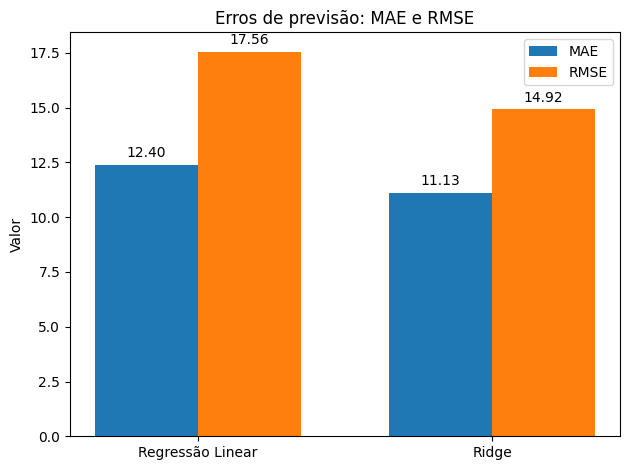

In [ ]:
# Obtém os nomes dos modelos da tabela de comparação
modelos = comparacao_modelos["Modelo"]

# Define a posição de cada modelo no eixo X
x = np.arange(len(modelos))

# Define a largura das barras
largura = 0.35

# Cria as barras do MAE
b1 = plt.bar(
    x - largura/2,
    comparacao_modelos["MAE"],
    largura,
    label="MAE"
)

# Cria as barras do RMSE
b2 = plt.bar(
    x + largura/2,
    comparacao_modelos["RMSE"],
    largura,
    label="RMSE"
)

# Define o título e os nomes dos eixos
plt.title("Erros de previsão: MAE e RMSE")
plt.ylabel("Valor")
plt.xticks(x, modelos)

# Exibe a legenda
plt.legend()

# Mostra o valor de cada barra
plt.bar_label(b1, fmt="%.2f", padding=3)
plt.bar_label(b2, fmt="%.2f", padding=3)

# Ajusta o espaçamento do gráfico
plt.tight_layout()

# Exibe o gráfico
plt.show()

**Explicação:** Este gráfico apresenta a comparação entre os modelos de Regressão Linear e Ridge por meio das métricas MAE e RMSE. O MAE representa o erro médio absoluto das previsões, enquanto o RMSE mede a magnitude dos erros dando maior peso aos erros mais elevados. Em ambas as métricas, valores menores indicam menor erro de previsão. A Regressão Linear apresentou MAE de 12,40 e RMSE de 17,56, enquanto o modelo Ridge apresentou MAE de 11,13 e RMSE de 14,92. Dessa forma, os resultados mostram uma redução dos erros no modelo Ridge em relação à Regressão Linear.

###61. Gráfico de erro quadrático médio (MSE)

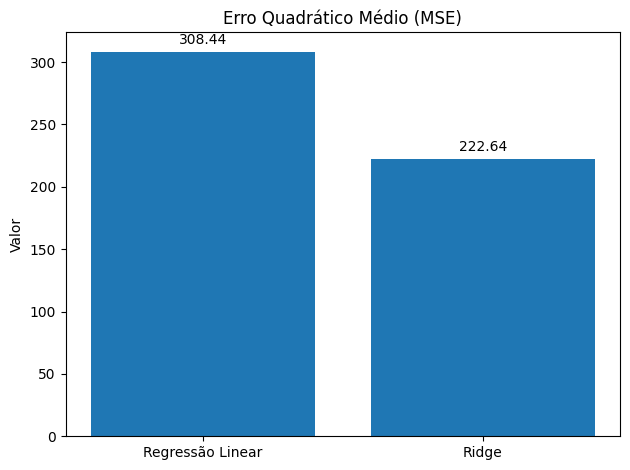

In [ ]:
# Obtém os nomes dos modelos da tabela de comparação
modelos = comparacao_modelos["Modelo"]

# Cria as barras utilizando os valores de MSE da tabela
b = plt.bar(
    modelos,
    comparacao_modelos["MSE"]
)

# Define o título e o nome do eixo Y
plt.title("Erro Quadrático Médio (MSE)")
plt.ylabel("Valor")

# Mostra o valor de MSE em cima de cada barra
plt.bar_label(b, fmt="%.2f", padding=3)

# Ajusta o espaçamento do gráfico
plt.tight_layout()

# Exibe o gráfico
plt.show()

**Explicação:** O segundo gráfico apresenta o MSE (Erro Quadrático Médio), que calcula a média dos erros ao quadrado e, por isso, atribui maior peso às previsões que apresentam erros mais elevados. Assim como no MAE e no RMSE, valores menores indicam menor erro. A Regressão Linear apresentou MSE de 308,44, enquanto o modelo Ridge apresentou 222,64, indicando uma redução dos erros quadráticos no modelo Ridge.

###62. Gráfico de R². Poder explicativo

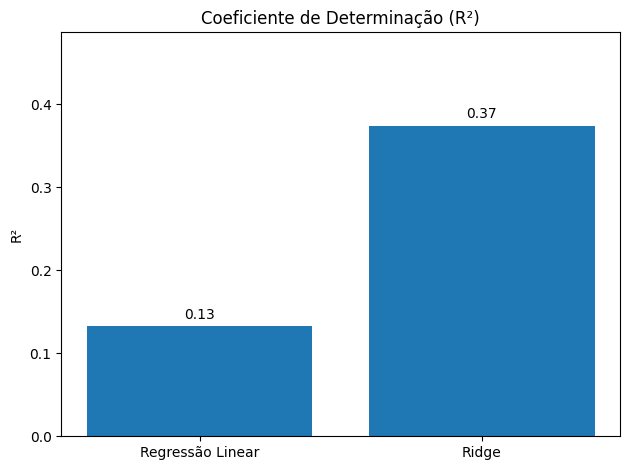

In [ ]:
# Obtém os nomes dos modelos da tabela de comparação
modelos = comparacao_modelos["Modelo"]

# Cria as barras utilizando os valores de R² da tabela
b = plt.bar(
    modelos,
    comparacao_modelos["R²"]
)

# Define o título e o nome do eixo Y
plt.title("Coeficiente de Determinação (R²)")
plt.ylabel("R²")

# Define o limite do eixo Y para facilitar a comparação visual
plt.ylim(0, max(comparacao_modelos["R²"]) * 1.3)

# Mostra o valor de R² em cima de cada barra
plt.bar_label(b, fmt="%.2f", padding=3)

# Ajusta o espaçamento do gráfico
plt.tight_layout()

# Exibe o gráfico
plt.show()

**Explicação:** O terceiro gráfico apresenta o coeficiente de determinação (R²), que indica quanto da variação da variável analisada é explicada pelo modelo. Nesse caso, a Regressão Linear apresentou R² de 0,13, enquanto o modelo Ridge apresentou R² de 0,37. Portanto, dentro dos dados utilizados no teste, o Ridge apresentou maior capacidade de explicar a variação observada do que a Regressão Linear. Entretanto, o resultado ainda indica que uma parcela significativa da variação não é explicada pelos modelos, demonstrando que o comportamento eleitoral de 1932, isoladamente, possui limitações para explicar as previsões de 1936.

# Conclusão

A pesquisa da Literary Digest de 1936 errou feio: previu 57% dos votos para Landon, mas Roosevelt ganhou com folga. O motivo não foi falta de dados, pois a revista recebeu cerca de 2,4 milhões de respostas. O problema foi a qualidade da amostra. As respostas vinham muito concentradas em poucos estados, então não representavam o país inteiro. Os cinco maiores estados sozinhos representaram 44,72% da amostra, e os dez maiores, 63,96%.

A comparação com a eleição de 1932 mostrou que o voto de um ano ajuda a explicar o do outro: a correlação foi de 0,93 para os democratas e 0,97 para os republicanos. Mas usar só um ano como referência tem limites. Olhar para eleições anteriores daria uma base mais sólida.

Na parte de modelagem, o Ridge foi melhor que a Regressão Linear. O MAE caiu de 12,40 para 11,13, uma redução de 10,24%. O RMSE caiu de 17,56 para 14,92, uma redução de 15,03%. E o R² subiu de 0,13 para 0,37. Mesmo assim, ainda sobra uma parte importante da variação sem explicação.

Vale destacar que o erro de 19 pontos da *Literary Digest* e o MAE dos modelos não são a mesma coisa, pois foram calculados de formas diferentes. A comparação serve para mostrar a diferença entre uma pesquisa com muitos dados, mas mal distribuídos, e uma análise que examina os dados, testa modelos e mede os erros.

No fim, a lição é simples: ter muitos dados não significa ter bons dados. Qualidade e representatividade da amostra são o que importa. Como melhoria futura, daria para incluir eleições anteriores a 1932 e usar técnicas de ponderação da amostra para uma análise mais robusta.
